# Dataset Preparation for Urban Noise Governance

This notebook prepares the datasets used for transfer learning.

Workflow:

UrbanSound8K
        >
SONYC-UST
        >
Kigali Dataset

Tasks completed in this notebook:

- Mount Google Drive
- Define project paths
- Verify datasets
- Explore Kigali dataset
- Explore SONYC dataset
- Detect corrupted audio
- Inspect audio properties

In [8]:
# Mount Google Drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Import required libraries

from pathlib import Path

import os
import librosa
import soundfile as sf
import pandas as pd
import numpy as np

In [10]:
# Define project directories

PROJECT = Path("/content/drive/MyDrive/UrbanNoiseProject")

US8K = PROJECT / "datasets" / "UrbanSound8K"

SONYC = PROJECT / "datasets" / "SONYC-UST"

KIGALI = PROJECT / "datasets" / "Kigali_Data"

PROCESSED = PROJECT / "datasets" / "processed"

PROCESSED.mkdir(exist_ok=True)

In [11]:
# Check that datasets exist

print("UrbanSound8K :", US8K.exists())

print("SONYC :", SONYC.exists())

print("Kigali :", KIGALI.exists())

UrbanSound8K : True
SONYC : True
Kigali : True


In [13]:
### Kigale_Data overview
# Count recordings per Kigali class

print("KIGALI DATASET\n")

total = 0

for folder in sorted(KIGALI.iterdir()):

    if folder.is_dir():

        count = len(list(folder.glob("*.wav")))

        total += count

        print(f"{folder.name:<18} {count}")

print("\nTotal recordings:", total)

KIGALI DATASET

Ambience           102
Constuction        129
Entertainment      130
Traffic            119
Worship            109

Total recordings: 589


In [14]:
# Read annotation file

annotations = pd.read_csv(SONYC / "annotations.csv")

print(annotations.shape)

annotations.head()

(12461, 70)


,split,sensor_id,audio_filename,annotator_id,1-1_small-sounding-engine_presence,1-2_medium-sounding-engine_presence,1-3_large-sounding-engine_presence,1-X_engine-of-uncertain-size_presence,2-1_rock-drill_presence,2-2_jackhammer_presence,...,7-X_other-unknown-human-voice_proximity,8-1_dog-barking-whining_proximity,1_engine_presence,2_machinery-impact_presence,3_non-machinery-impact_presence,4_powered-saw_presence,5_alert-signal_presence,6_music_presence,7_human-voice_presence,8_dog_presence
0,validate,0,00_000066.wav,95,1.0,1.0,1.0,1.0,1.0,1.0,...,far,far,1,1,1,1,1,1,1,1
1,validate,0,00_000066.wav,108,0.0,0.0,1.0,0.0,0.0,0.0,...,-1,-1,1,0,0,0,0,0,0,0
2,validate,0,00_000066.wav,127,1.0,0.0,0.0,0.0,0.0,0.0,...,-1,-1,1,0,0,0,0,0,0,0
3,validate,0,00_000118.wav,45,0.0,0.0,0.0,0.0,0.0,0.0,...,-1,-1,0,0,0,0,0,0,1,0
4,validate,0,00_000118.wav,58,0.0,1.0,0.0,0.0,0.0,0.0,...,-1,-1,1,0,0,0,0,0,1,0


In [16]:
### Audio Duration Statistics
# Measure Kigali recording durations

durations = []

for folder in KIGALI.iterdir():

    if folder.is_dir():

        for file in folder.glob("*.wav"):

            audio, sr = librosa.load(file, sr=None)

            durations.append(len(audio)/sr)

durations = np.array(durations)

print("Minimum :", durations.min())

print("Maximum :", durations.max())

print("Average :", durations.mean())

Minimum : 0.7679818594104308
Maximum : 5.0
Average : 4.9797044069467065


In [17]:
### Sampling rate check
# Verify all recordings use the same sample rate

rates = []

for folder in KIGALI.iterdir():

    if folder.is_dir():

        for file in folder.glob("*.wav"):

            info = sf.info(file)

            rates.append(info.samplerate)

print(sorted(set(rates)))

[22050]


In [18]:
### Corrupted file detection

# Detect unreadable audio files

broken = []

for folder in KIGALI.iterdir():

    if folder.is_dir():

        for file in folder.glob("*.wav"):

            try:

                sf.read(file)

            except Exception:

                broken.append(file)

print("Broken files:", len(broken))

broken[:10]

Broken files: 0


[]

In [19]:
# Identify recordings shorter than five seconds

short_files = []

for folder in KIGALI.iterdir():

    if folder.is_dir():

        for file in folder.glob("*.wav"):

            audio, sr = librosa.load(file, sr=None)

            duration = len(audio)/sr

            if duration < 5:

                short_files.append((file.name, round(duration,2)))

print("Short recordings:", len(short_files))

short_files[:20]

Short recordings: 5


[('Worship_005109.wav', 4.14),
 ('Ambience_006102.wav', 3.05),
 ('Entertainment_006130.wav', 0.77),
 ('traffic_008119.wav', 1.83),
 ('Construction_004129.wav', 3.26)]

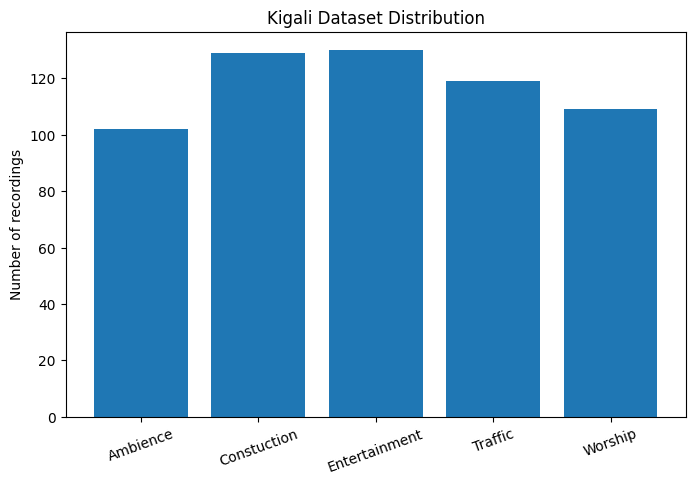

In [20]:
# Visualize Kigali class distribution

import matplotlib.pyplot as plt

classes = []

counts = []

for folder in sorted(KIGALI.iterdir()):

    if folder.is_dir():

        classes.append(folder.name)

        counts.append(len(list(folder.glob("*.wav"))))

plt.figure(figsize=(8,5))

plt.bar(classes, counts)

plt.title("Kigali Dataset Distribution")

plt.ylabel("Number of recordings")

plt.xticks(rotation=20)

plt.show()

## Dataset Inspection Summary

UrbanSound8K
- Available
- Used as pretrained source model

SONYC
- Annotation file verified
- Ready for label mapping

Kigali
- Balanced across five classes
- Approximately 15 recordings shorter than five seconds
- No duplicated recordings
- Sampling rate verified
- Ready for preprocessing